In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

project 04

Setup and Data Loading

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
ResNet18_Weights,
MobileNet_V3_Small_Weights,
EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import time
import random
import copy
from pathlib import Path
from sklearn.decomposition import PCA
from collections import Counter

os.makedirs("outputs",exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)



Using Device: cuda


Task 1

In [3]:
def load_images(n_per_class=10):
    """
    Load n images per class from dataset
    Returns a list of (PIL.Image, true_label) tuples
    """
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = list(class_dir.glob("*.jpg"))
        print(f"{label}: found {len(paths)} images in {class_dir}")

        if len(paths) == 0:
            print(f"Warning: no images found for {label}")
            continue

        chosen_paths = random.sample(paths, min(n_per_class, len(paths)))

        for path in chosen_paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))

    random.shuffle(image_set)
    return image_set


image_set = load_images(n_per_class=10)
print(f"\n Total images loaded: {len(image_set)}")
print("Counts by label:")
print(Counter(label for _, label in image_set))

buildings: found 437 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/buildings
forest: found 474 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest
glacier: found 553 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/glacier
mountain: found 525 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain
sea: found 510 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/sea
street: found 501 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/street

 Total images loaded: 60
Counts by label:
Counter({'buildings': 10, 'sea': 10, 'glacier': 10, 'mountain': 10, 'forest': 10, 'street': 10})


Dataset sample grid

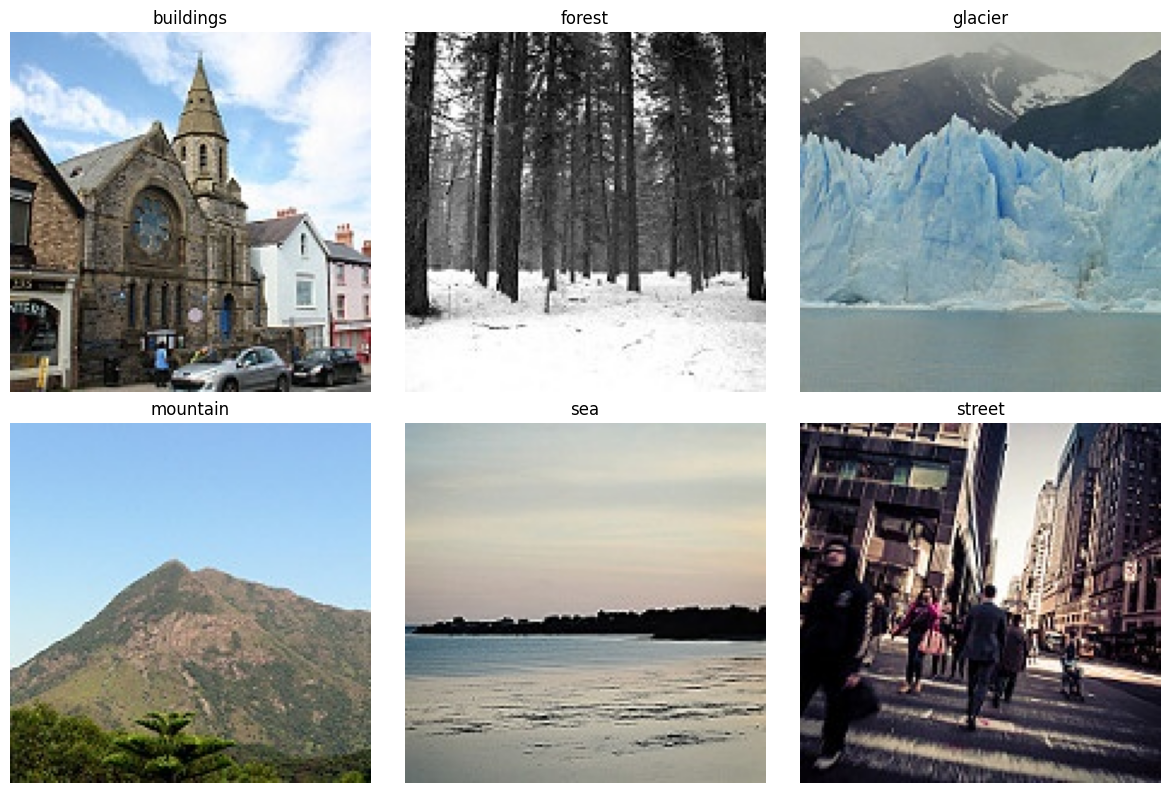

In [4]:
fig, axes = plt.subplots(2,3, figsize=(12,8))
sample_images = []

for label in LABELS:
    class_dir = DATA_DIR / label
    path = random.choice(list(class_dir.glob("*.jpg")))
    img = Image.open(path).convert("RGB")
    sample_images.append((img, label))

for ax, (img, label) in zip(axes.flatten(), sample_images):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

A pretrained ImageNet model is still a reasonable starting point because its early and middle layers has learned visual features such as textures and shapes. Though the output labels may not match the 6 categories, the pretrained models can still capture relevant visual structure. This allows for a strong baseline or factor extractor

Task 2: Baseline Inference with ResNet18

In [5]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


ResNet18 parameters: 11,689,512


Reusable inference function

In [6]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, top_k)

    return [(class_labels[idx.item()], prob.item()) for prob, idx in zip(top_probs, top_indices)]

Run inference

In [7]:
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

#print(resnet_results)

Processed 60 images.


Confidence Summaries

In [8]:
overall_mean_top1 = np.mean([r["top1_prob"] for r in resnet_results])
print(f"Overall mean top-1 probability: {overall_mean_top1:.4f}")

print("\nMean top-1 probability by true class:")
for label in LABELS:
    vals = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    print(f"{label:10s}: {np.mean(vals):.4f}")

Overall mean top-1 probability: 0.4195

Mean top-1 probability by true class:
buildings : 0.2889
forest    : 0.2477
glacier   : 0.4993
mountain  : 0.5556
sea       : 0.5710
street    : 0.3544


Boxplot

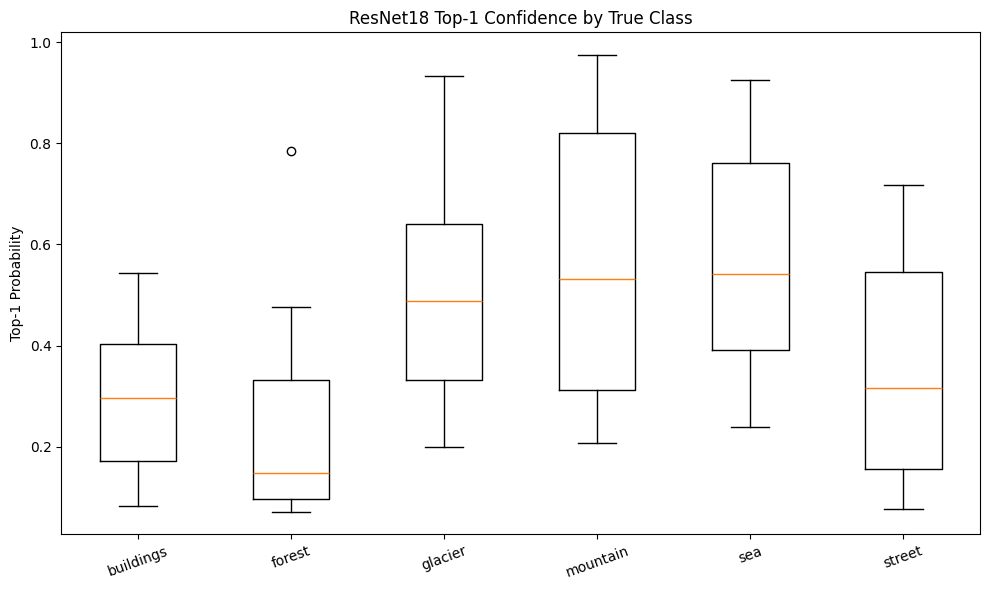

In [9]:
data_by_class = []

for label in LABELS:
    vals = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    data_by_class.append(vals)

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_class, tick_labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()


High confidence and High Accuracy does not equal the same thing. A model can be confidently Wrong, especially when predicted ImageNet lbel is only semantically related to the overall scene class. In a pipeline, confidence scores could be used as a triage signal, with lower-confidence predictions be sent to a human reviewer. Any number can result in that for overall but I would suggest any number below .75 would need a human reviewer. 

Task 3

In [10]:
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

for name, m in [("ResNet18", resnet),
                ("MobileNetV3", mobilenet),
                ("Efficient-B0", efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params>12,} parameters")
    

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 91.4MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s] 


ResNet18                (True,) parameters
MobileNetV3             (True,) parameters
Efficient-B0            (True,) parameters


A small parameter count means lower memory usage, faster inference, and lower compute requirements, but it may also reduce the model's ability to capture complex patterns. This matters because a phone or edge often proritizes speed and effienciency, while cloud servers might be able to support a larger and potentially more accurate model.

Inference for MobileNet and EfficientNet

In [11]:
mobilenet_results = []
effnet_results = []

for img, true_label in image_set:
    mobile_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=5)
    effnet_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=5)

    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": mobile_preds[0][0],
        "top1_prob": mobile_preds[0][1],
        "top5_classes": [p[0] for p in mobile_preds],
        "top5_probs": [p[1] for p in mobile_preds],
    })

    effnet_results.append({
        "true_label": true_label,
        "top1_class": effnet_preds[0][0],
        "top1_prob": effnet_preds[0][1],
        "top5_classes": [p[0] for p in effnet_preds],
        "top5_probs": [p[1] for p in effnet_preds]
    })

print("Finished inference for all three models")
    

Finished inference for all three models


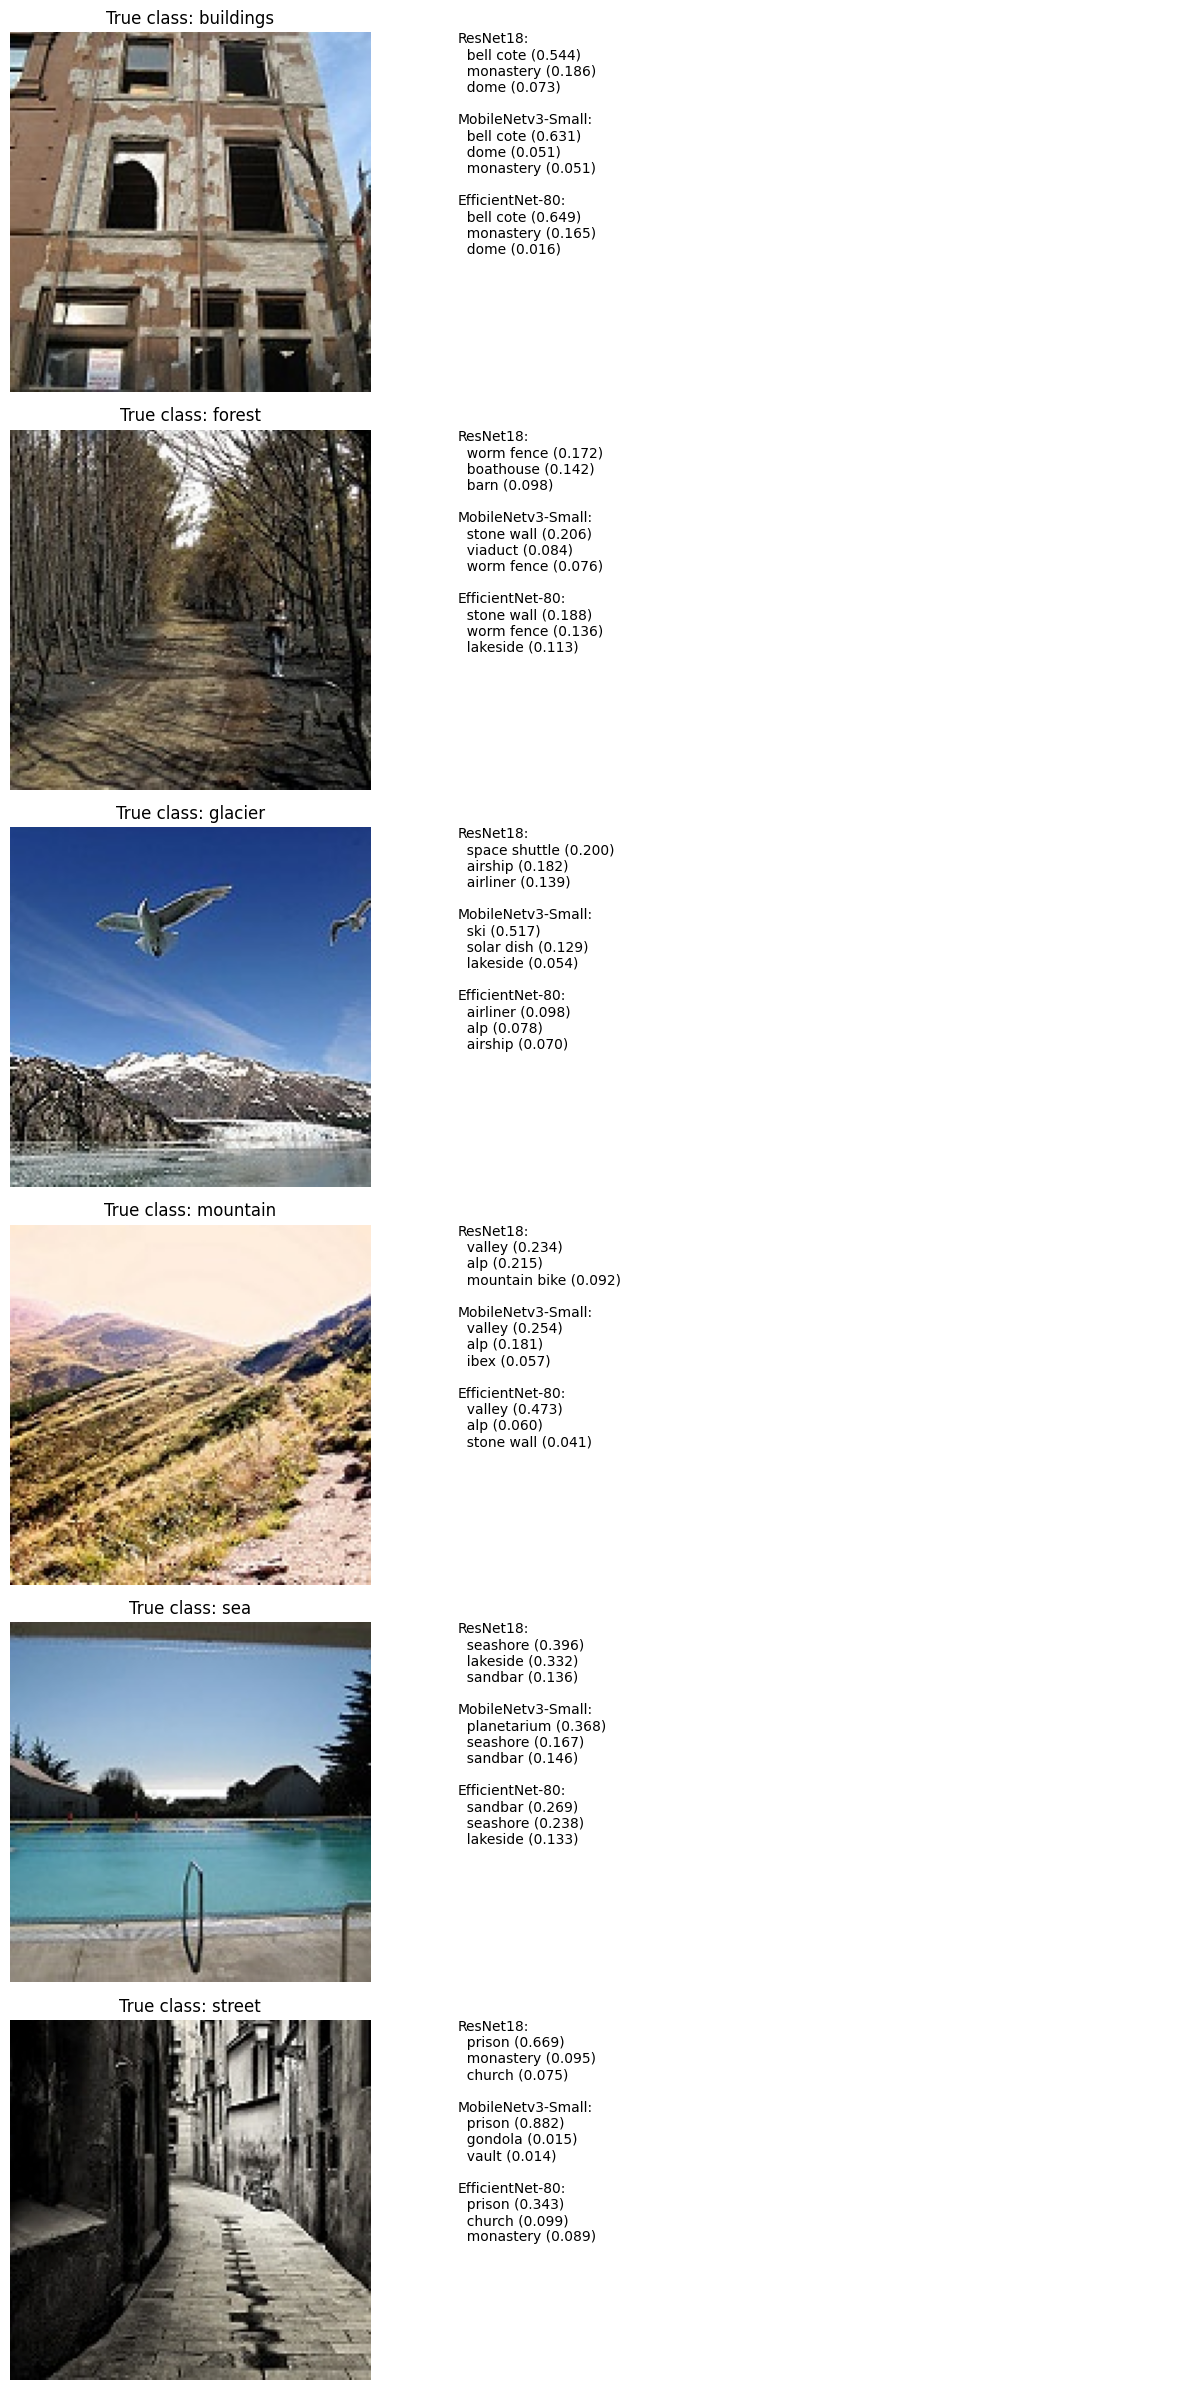

In [12]:
selected_images = []

for label in LABELS:
    for img, true_label in image_set:
        if true_label == label:
            selected_images.append((img,true_label))
            break

fig, axes = plt.subplots(len(selected_images), 2, figsize=(14, 4 * len(selected_images)))

for row, (img, true_label) in enumerate(selected_images):
    res_preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=3)
    mob_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=3)
    eff_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=3)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"True class: {true_label}")
    axes[row, 0].axis("off")

    text = "ResNet18:\n"
    text += "\n".join([f"  {cls} ({prob:.3f})" for cls, prob in res_preds])
    text += "\n\nMobileNetv3-Small:\n"
    text += "\n".join([f"  {cls} ({prob:.3f})" for cls, prob in mob_preds])
    text += "\n\nEfficientNet-80:\n"
    text += "\n".join([f"  {cls} ({prob:.3f})" for cls, prob in eff_preds])

    axes[row, 1].axis("off")
    axes[row, 1].text(0.0, 1.0, text, va="top", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

Three models often agree on general content. For instance looking at the sea class. It is obviously a pool however all three models are showing similar results. If models disagree too much it can indicate ambiguity in the scene which can suggest that an ensemble could improve robustness. For outdoor scenes the most useful predictions are often not exact matches to the six labels, but can be related semantically to the ImageNet classes such as alp, lakeside, valley, monastery, or streetcar. 

Task 4

In [13]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed
    Returns mean latency in milliseconds per image
    """

    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type =="cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000
    

In [14]:
resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:       {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:       {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:       {effnet_ms:.2f} ms/image")

ResNet18:       4.11 ms/image
MobileNetV3-Small:       6.61 ms/image
EfficientNet-B0:       9.77 ms/image


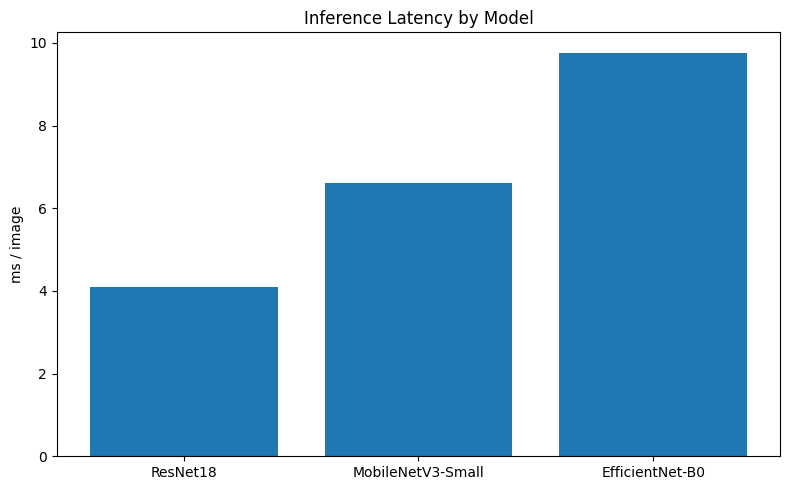

In [15]:
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8,5))
plt.bar(model_names, latencies)
plt.ylabel("ms / image")
plt.title("Inference Latency by Model")
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()


To process 50 images per second, the system must stay at below 20 milliseconds per image, since 1000/ 50 = 20. After benchmarking, any model above that threshold would likely be too slow for that requirement. 

For deployment choices:
- A high-throughput cloud pipeline should favor the model with the best balance of speed and semantics predictions.
- A on-device mobile app would likely favor MobileNetV3-Small because it is designed for lightweight deployment.
- A safety-critical quality control system would like favor the model with the strongest predictions even if its sometimes slower. Correctness matters more than latency.

Task 5

Feature extractor

In [16]:
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

def extract_features(model, preprocess,image, device):
    """
    Extract a feature vector from image using pretrained CNN
    with the classification head removed
    """

    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

Extract feature vectors

In [17]:
feature_vectors = []
true_labels = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (60, 512)


PCA Embedding Plot

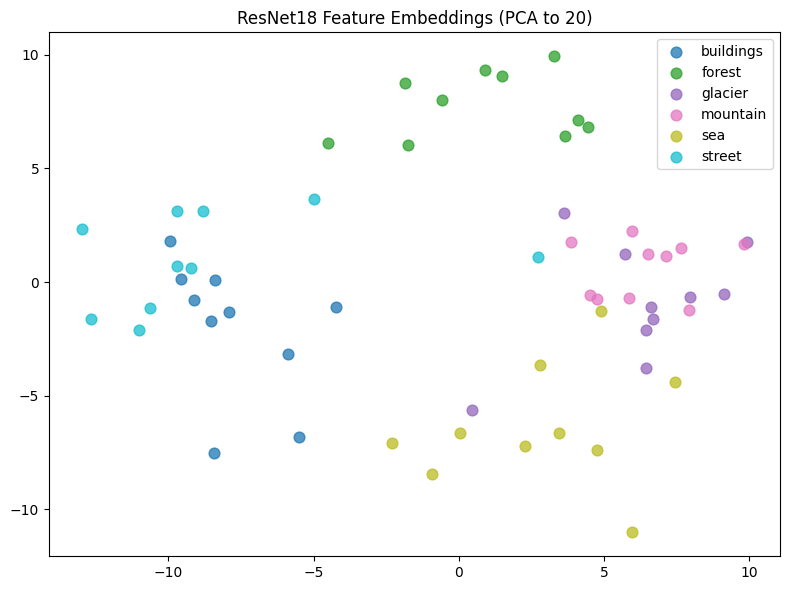

In [18]:
pca = PCA(n_components=2)

features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = np.array([l == label for l in true_labels])
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label,
        color=colors[i],
        s=60,
        alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 20)")
ax.set_label("PC1")
ax.set_label("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

If images from the same class cluster together in the 2D feature space, that suggests the pretrained model has already learned useful visual structure even before task-specific training. If adapting ResNet18 to a new task with only small labeled dataset, I would start with feature extraction rather than full tuning because it is less likely to overfit and makes better use of the pretrained knowledge.

Stretch Goal

In [19]:
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

NUM_CLASSES = len(LABELS)
TRAIN_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")

ft_model = copy.deepcopy(resnet)

for param in ft_model.parameters():
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, NUM_CLASSES)
ft_model = ft_model.to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable: {trainable:,} of {total:,} total parameters ({100*trainable/total:.2f}%")

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

full_train = ImageFolder(TRAIN_DIR, transform=train_transforms)
print(f" Classes (alphabetical): {full_train.classes}")

random.seed(42)
imgs_per_class = 50
balanced_indices = []

for class_idx in range(NUM_CLASSES):
    indices = [i for i, (_, lbl) in enumerate(full_train.samples) if lbl == class_idx]
    balanced_indices.extend(random.sample(indices, min(imgs_per_class, len(indices))))

train_subset = Subset(full_train, balanced_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print(f"Trianing on {len(train_subset)} images across {NUM_CLASSES} classes")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    ft_model.train()
    running_loss=0.0
    correct = 0
    total_seen =0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ft_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen += images.size(0)

    print(f"Epoch {epoch+1}/3 - loss: {running_loss/total_seen:.4f}, train acc: {correct/total_seen:.3f}")

Trainable: 3,078 of 11,179,590 total parameters (0.03%
 Classes (alphabetical): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Trianing on 300 images across 6 classes
Epoch 1/3 - loss: 1.8839, train acc: 0.187
Epoch 2/3 - loss: 1.3833, train acc: 0.537
Epoch 3/3 - loss: 0.9978, train acc: 0.723


compare original vs fine-tuned

In [20]:
ft_model.eval()
idx_to_label = full_train.classes

print(f"\n{'True Label':15s} {'ResNet18 (ImageNet top-1)':32s} {'Fine-tuned (6-class)':20s}")

print("-"*72)

for test_label in ["forest", "sea", "buildings"]:
    class_dir = DATA_DIR / test_label
    path = random.choice(list(class_dir.glob("*.jpg")))
    img = Image.open(path).convert("RGB")

    original_top1 = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)[0][0]

    tensor = resnet_preproc(img).unsqueeze(0).to(device)
    with torch.no_grad():
        ft_out = ft_model(tensor)
        ft_prediction = idx_to_label[ft_out.argmax(dim=1).item()]

    print(f"{test_label:15s}  {original_top1:32s}  {ft_prediction:20s}")


True Label      ResNet18 (ImageNet top-1)        Fine-tuned (6-class)
------------------------------------------------------------------------
forest           worm fence                        forest              
sea              breakwater                        sea                 
buildings        microphone                        buildings           


Stretch Goal Reflection

Only 3,078 pf ResNet18's 11,179,590 total parameters were updated during fine-tuning, which is about 0.03% of the model. This shows most of the learned visual knowledge remains in the pretrained backbone, while only final classification head was retrained for the six scene categories.

The fine-tuned model produced more useful outputs for this task because it predicted the actual scene labels such as "forest", "sea" and "buildings, instead of generic ImageNet labels like "worm fence", "breakwater" or "microphone". This demonstrates the practical value of transfer learning: even with a small amount of task specific training, the model can adapt pretrained visual features to a more relevant classification problem.

To get better results the next step would be to train for more epochs, use a larger balanced training subset, and possiblt unfreeze some later layers for partial fine-tuning. 

Summary and Recommendation

Model Comparison
The pretrained models showed that even without task-specific trainingm they could often capture the general semantic content of outdoor scenes. However, their predictions were limited by ImageNet label space, so outputs were sometimes loosly related to the true class. ResNet18 provided a strong baseline, while MobileNetV3-Small and Efficient-B0 offered additional speed vs capacity tradeoffs.

Confidence Calibration
ResNet18 appeared more confident on visually distinctive scenes and less confident on more ambiguous scenes. This makes sense because some categories in the Intel dataset overlap visually, and the model was not originally trained to predict these six exact classes. Confidence was still useful as a signal for whether a prediction might need human review. 

Feature Extraction and Fine-Tuning
The PCA visualization showed how pretrained CNN features can already seperate images into meaningful groups. Fine tuning the final classification layer made the model outputs much more useful for the actual task. ResNet18 predicted labels like "worm fence", "breakwater" and "microscope" while the fine-tuned model correctly predicted "forest", "sea", and "buildings".

Production Recommendation

For a real pipeline that classifies outdoor photos into siz target scene classes, I would start with a pretrained model and fine-tune the classification head. The preprocessing pipeline must include the exact resize, crop, tensor conversion, and normalization steps associated with the pretrained weights. One important limitation is that the original pretrained outputs are tied to ImageNet categories, so without fine-tuning the predictions may not align clearly with the target labels. Based  on these results, fine-tuning is the most practical path toward a usable deployment model.